### Using this dataset, predict whether annual income of an individual exceeds $50K/yr based on census data. Properly study the dataset and problem statement. Perform all the relevant data wrangling and EDA. Use all the classification algorithms you have learnt till now including ensemble learnings and compare and interpret their performances. [You could drop irrelevant features] [Try to visualize every steps with proper charts and graphs.]

In [1]:
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
adult = fetch_ucirepo(id=2) 
  
# data (as pandas dataframes) 
X = adult.data.features 
y = adult.data.targets 
  
# metadata 
print(adult.metadata) 
  
# variable information 
print(adult.variables) 


{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

In [3]:
# make a dafaframe with the data and target
import pandas as pd
df = pd.DataFrame(X)
df['target'] = y
# show the first few rows of the dataframe  
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [6]:
df.shape

(48842, 15)

In [7]:
df.duplicated().sum()

29

In [8]:
# reomving duplicates
df = df.drop_duplicates()

In [9]:
df.shape


(48813, 15)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48813 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48813 non-null  int64 
 1   workclass       47850 non-null  object
 2   fnlwgt          48813 non-null  int64 
 3   education       48813 non-null  object
 4   education-num   48813 non-null  int64 
 5   marital-status  48813 non-null  object
 6   occupation      47847 non-null  object
 7   relationship    48813 non-null  object
 8   race            48813 non-null  object
 9   sex             48813 non-null  object
 10  capital-gain    48813 non-null  int64 
 11  capital-loss    48813 non-null  int64 
 12  hours-per-week  48813 non-null  int64 
 13  native-country  48539 non-null  object
 14  target          48813 non-null  object
dtypes: int64(6), object(9)
memory usage: 6.0+ MB


In [12]:
df['target'].value_counts()

target
<=50K     24698
<=50K.    12430
>50K       7839
>50K.      3846
Name: count, dtype: int64

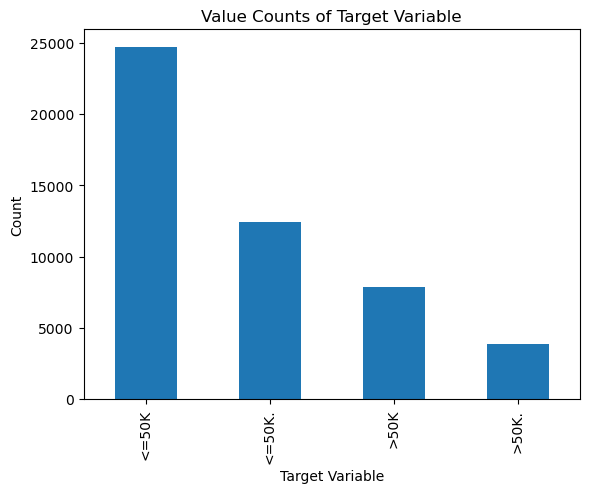

In [11]:
# plot the value counts of target variable
import matplotlib.pyplot as plt
df['target'].value_counts().plot(kind='bar')
plt.title('Value Counts of Target Variable')
plt.xlabel('Target Variable')
plt.ylabel('Count')
plt.show()

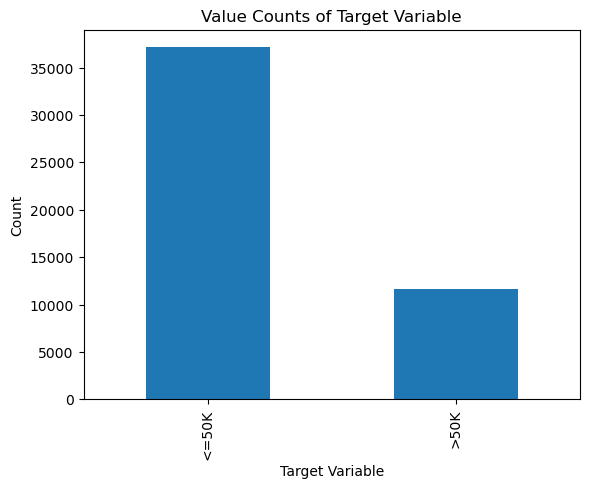

In [13]:
df['target'] = df['target'].replace({
    '<=50K.': '<=50K',
    '>50K.': '>50K'
})

df['target'].value_counts().plot(kind='bar')
plt.title('Value Counts of Target Variable')
plt.xlabel('Target Variable')
plt.ylabel('Count')
plt.show()

In [14]:
df['target'].value_counts()

target
<=50K    37128
>50K     11685
Name: count, dtype: int64

seems to be imbalanced

In [5]:
df.isnull().sum()  # check for missing values

age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
target              0
dtype: int64

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48813 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48813 non-null  int64 
 1   workclass       47850 non-null  object
 2   fnlwgt          48813 non-null  int64 
 3   education       48813 non-null  object
 4   education-num   48813 non-null  int64 
 5   marital-status  48813 non-null  object
 6   occupation      47847 non-null  object
 7   relationship    48813 non-null  object
 8   race            48813 non-null  object
 9   sex             48813 non-null  object
 10  capital-gain    48813 non-null  int64 
 11  capital-loss    48813 non-null  int64 
 12  hours-per-week  48813 non-null  int64 
 13  native-country  48539 non-null  object
 14  target          48813 non-null  object
dtypes: int64(6), object(9)
memory usage: 6.0+ MB


In [20]:
# function to plot distribution of a continuous variable
import seaborn as sns
def plot_distribution(df, column):
    plt.figure(figsize=(10, 6))
    df[column].hist(bins=30, edgecolor='black')
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.grid(False)
    plt.show()

In [22]:
# plot distribution of numerical features
numerical_features= df.select_dtypes(include=['int64', 'float64']).columns
numerical_features



Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

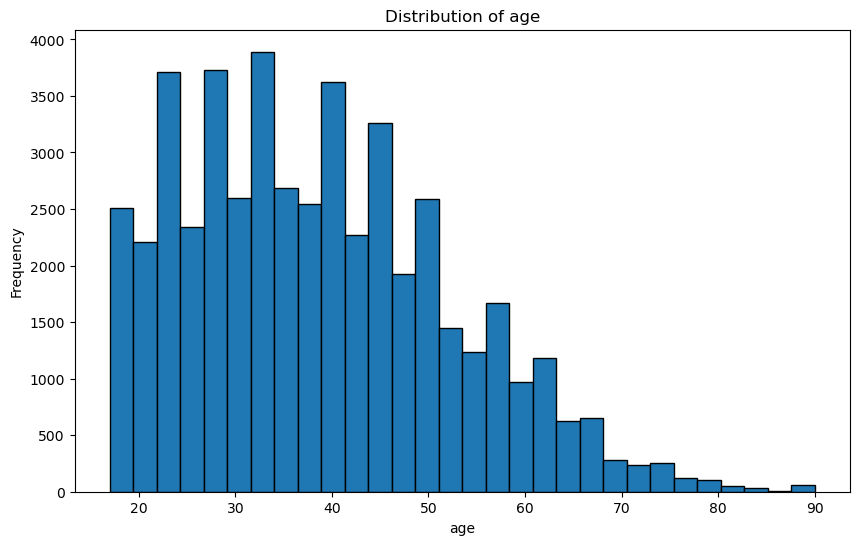

In [23]:
plot_distribution(df, 'age')

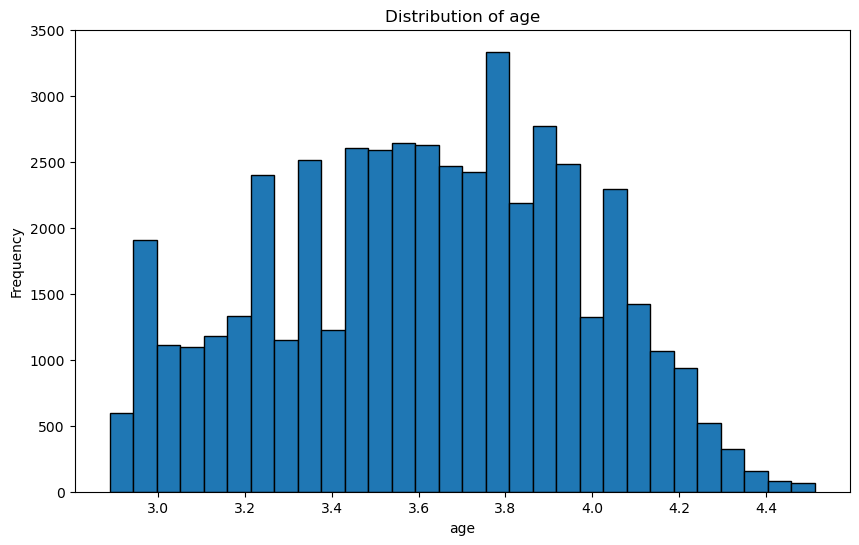

In [24]:
import numpy as np

df['age'] = np.log(df['age'] + 1)  # +1 to avoid log(0) if age has 0

plot_distribution(df, 'age')

In [27]:
df.isnull().sum()  # check for missing values
# check the data types of the columns

age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
target              0
dtype: int64

In [28]:
df['workclass'].value_counts()

workclass
Private             33879
Self-emp-not-inc     3861
Local-gov            3136
State-gov            1981
?                    1836
Self-emp-inc         1694
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

In [29]:
df['workclass'] = df['workclass'].replace('?', np.nan)
df.isnull().sum()  # check for missing values again

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation         966
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     274
target               0
dtype: int64

In [30]:
df['workclass'].fillna('Unknown', inplace=True)
df.isnull().sum()  # check for missing values again

C:\Users\user\AppData\Local\Temp\ipykernel_20804\3564724290.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['workclass'].fillna('Unknown', inplace=True)


age                 0
workclass           0
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
target              0
dtype: int64

In [32]:
df['occupation'].value_counts()

occupation
Prof-specialty       6167
Craft-repair         6107
Exec-managerial      6084
Adm-clerical         5608
Sales                5504
Other-service        4919
Machine-op-inspct    3019
Transport-moving     2355
Handlers-cleaners    2071
?                    1843
Farming-fishing      1487
Tech-support         1445
Protective-serv       983
Priv-house-serv       240
Armed-Forces           15
Name: count, dtype: int64

In [33]:
df['occupation'] = df['occupation'].replace('?', np.nan)
df['occupation'].fillna('Unknown', inplace=True)


C:\Users\user\AppData\Local\Temp\ipykernel_20804\1860942263.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['occupation'].fillna('Unknown', inplace=True)


In [34]:
df.isnull().sum()  # check for missing values again

age                 0
workclass           0
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation          0
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
target              0
dtype: int64

In [35]:
df['native-country'].value_counts() 

native-country
United-States                 43810
Mexico                          947
?                               582
Philippines                     295
Germany                         206
Puerto-Rico                     184
Canada                          182
El-Salvador                     155
India                           151
Cuba                            138
England                         127
China                           122
South                           115
Jamaica                         106
Italy                           105
Dominican-Republic              103
Japan                            92
Poland                           87
Guatemala                        86
Vietnam                          86
Columbia                         85
Haiti                            75
Portugal                         67
Taiwan                           65
Iran                             59
Greece                           49
Nicaragua                        49
Peru         

In [37]:
# Treat '?' as missing
df['native-country'] = df['native-country'].replace('?', np.nan)

# Fill missing with mode (most frequent value)
df['native-country'].fillna(df['native-country'].mode()[0], inplace=True)


C:\Users\user\AppData\Local\Temp\ipykernel_20804\451851766.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['native-country'].fillna(df['native-country'].mode()[0], inplace=True)


In [38]:
df.isnull().sum()  # check for missing values again

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
target            0
dtype: int64

In [39]:
df.duplicated().sum()  # check for duplicates again

23

In [40]:
# remove duplicates again if any
df = df.drop_duplicates()
df.duplicated().sum()  # check for duplicates again

0

In [41]:
df.isnull().sum()  # check for missing values again

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
target            0
dtype: int64

In [36]:
df['native-country'].unique()

array(['United-States', 'Cuba', 'Jamaica', 'India', '?', 'Mexico',
       'South', 'Puerto-Rico', 'Honduras', 'England', 'Canada', 'Germany',
       'Iran', 'Philippines', 'Italy', 'Poland', 'Columbia', 'Cambodia',
       'Thailand', 'Ecuador', 'Laos', 'Taiwan', 'Haiti', 'Portugal',
       'Dominican-Republic', 'El-Salvador', 'France', 'Guatemala',
       'China', 'Japan', 'Yugoslavia', 'Peru',
       'Outlying-US(Guam-USVI-etc)', 'Scotland', 'Trinadad&Tobago',
       'Greece', 'Nicaragua', 'Vietnam', 'Hong', 'Ireland', 'Hungary',
       'Holand-Netherlands', nan], dtype=object)

In [25]:
numerical_features

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

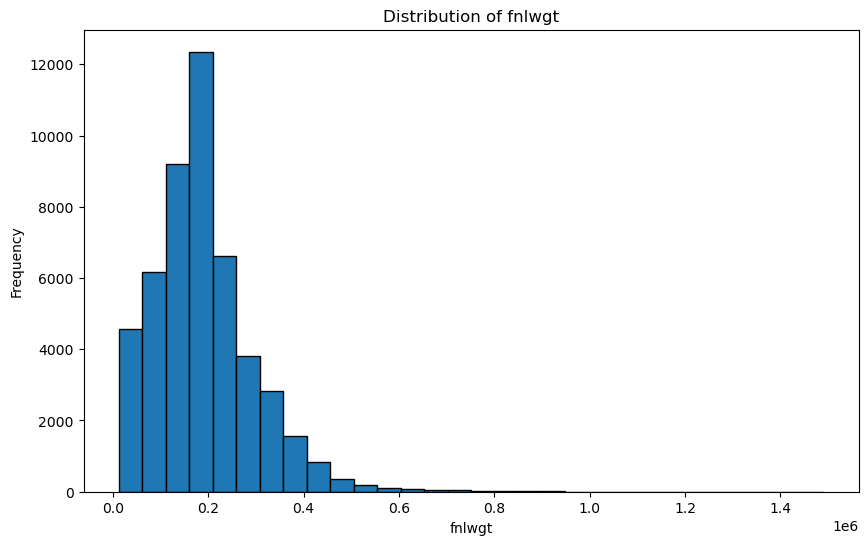

In [26]:
plot_distribution(df, 'fnlwgt')

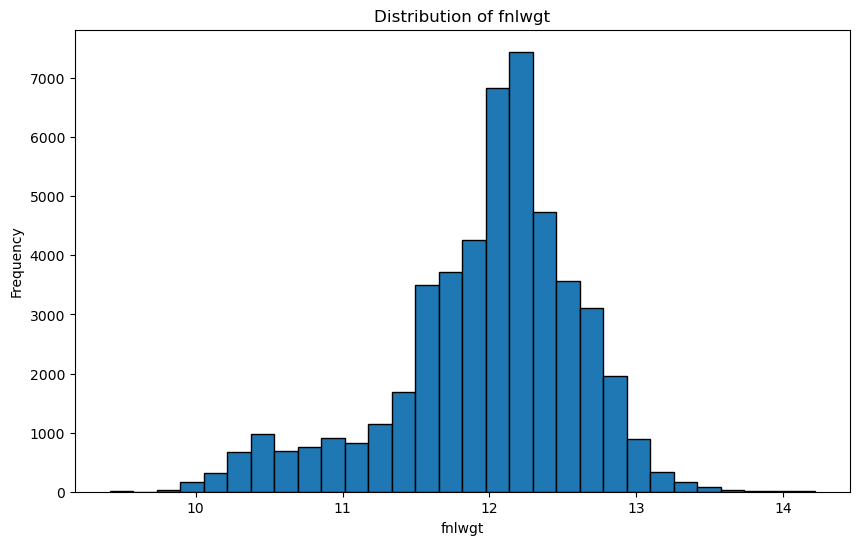

In [42]:
# apply log transformation to 'fnlwgt'
df['fnlwgt'] = np.log(df['fnlwgt'] + 1)  # +1 to avoid log(0) if fnlwgt has 0
plot_distribution(df, 'fnlwgt')

In [43]:
numerical_features

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

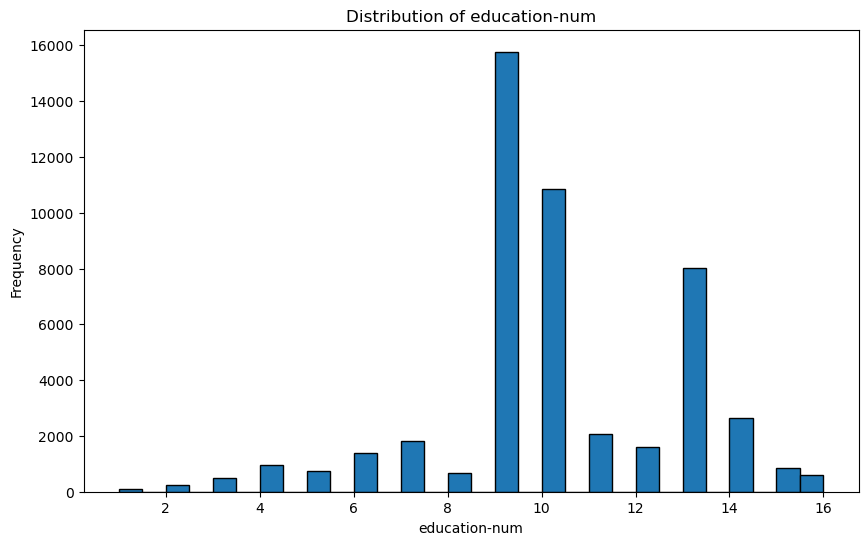

In [44]:
plot_distribution(df, 'education-num')

In [45]:
df['education-num'].unique()

array([13,  9,  7, 14,  5, 10, 12, 11,  4, 16, 15,  3,  6,  2,  1,  8],
      dtype=int64)

In [48]:
df['capital-gain'].describe()

count    48790.000000
mean      1080.217688
std       7455.905921
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-gain, dtype: float64

In [50]:
df['capital-gain'].unique()

array([ 2174,     0, 14084,  5178,  5013,  2407, 14344, 15024,  7688,
       34095,  4064,  4386,  7298,  1409,  3674,  1055,  3464,  2050,
        2176,   594, 20051,  6849,  4101,  1111,  8614,  3411,  2597,
       25236,  4650,  9386,  2463,  3103, 10605,  2964,  3325,  2580,
        3471,  4865, 99999,  6514,  1471,  2329,  2105,  2885, 25124,
       10520,  2202,  2961, 27828,  6767,  2228,  1506, 13550,  2635,
        5556,  4787,  3781,  3137,  3818,  3942,   914,   401,  2829,
        2977,  4934,  2062,  2354,  5455, 15020,  1424,  3273, 22040,
        4416,  3908, 10566,   991,  4931,  1086,  7430,  6497,   114,
        7896,  2346,  3418,  3432,  2907,  1151,  2414,  2290, 15831,
       41310,  4508,  2538,  3456,  6418,  1848,  3887,  5721,  9562,
        1455,  2036,  1831, 11678,  2936,  2993,  7443,  6360,  1797,
        1173,  4687,  6723,  2009,  6097,  2653,  1639, 18481,  7978,
        2387,  5060,  1264,  7262,  1731,  6612], dtype=int64)

In [52]:
df['capital-gain'] = df['capital-gain'].apply(lambda x: 1 if x > 0 and x < 99999 else 0)


In [53]:
df['capital-gain'].value_counts()

capital-gain
0    44999
1     3791
Name: count, dtype: int64

In [54]:
df['capital-loss'].describe()

count    48790.000000
mean        87.595573
std        403.209129
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       4356.000000
Name: capital-loss, dtype: float64

In [56]:
df['capital-loss'].unique()

array([   0, 2042, 1408, 1902, 1573, 1887, 1719, 1762, 1564, 2179, 1816,
       1980, 1977, 1876, 1340, 2206, 1741, 1485, 2339, 2415, 1380, 1721,
       2051, 2377, 1669, 2352, 1672,  653, 2392, 1504, 2001, 1590, 1651,
       1628, 1848, 1740, 2002, 1579, 2258, 1602,  419, 2547, 2174, 2205,
       1726, 2444, 1138, 2238,  625,  213, 1539,  880, 1668, 1092, 1594,
       3004, 2231, 1844,  810, 2824, 2559, 2057, 1974,  974, 2149, 1825,
       1735, 1258, 2129, 2603, 2282,  323, 4356, 2246, 1617, 1648, 2489,
       3770, 1755, 3683, 2267, 2080, 2457,  155, 3900, 2201, 1944, 2467,
       2163, 2754, 2472, 1411, 1429, 3175, 1510, 1870, 1911, 2465, 1421],
      dtype=int64)

In [ ]:
df['capital-loss'] = df['capital-loss'].apply(lambda x: 1 if x > 0 and x < 99999 else 0)


In [51]:
df['target'].value_counts()

target
<=50K    37109
>50K     11681
Name: count, dtype: int64

In [57]:
df.to_csv('1_preprocessed.csv', index=False)

In [58]:
numerical_features

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

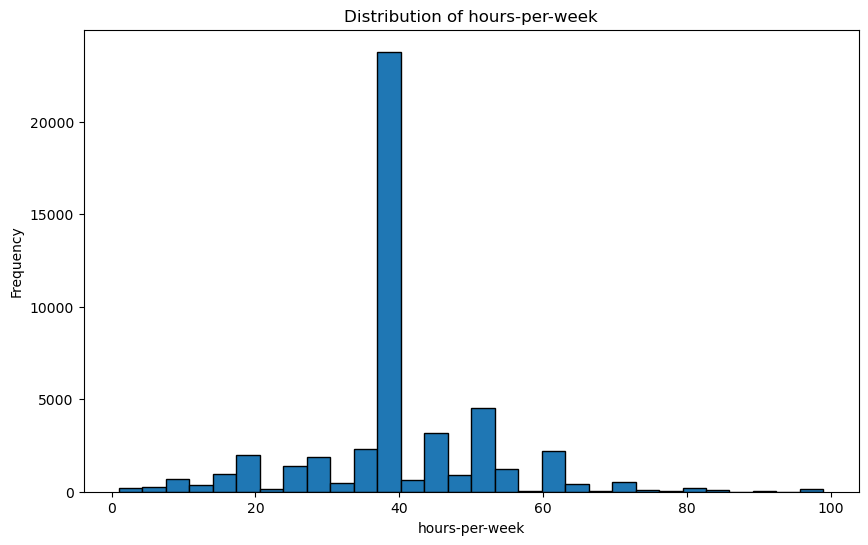

In [59]:
plot_distribution(df, 'hours-per-week')

In [60]:
df['hours-per-week'].describe()

count    48790.000000
mean        40.425886
std         12.392729
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours-per-week, dtype: float64

In [61]:
#function to show boxplot of a numerical feature
def plot_boxplot(df, column):
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
    plt.grid(False)
    plt.show()

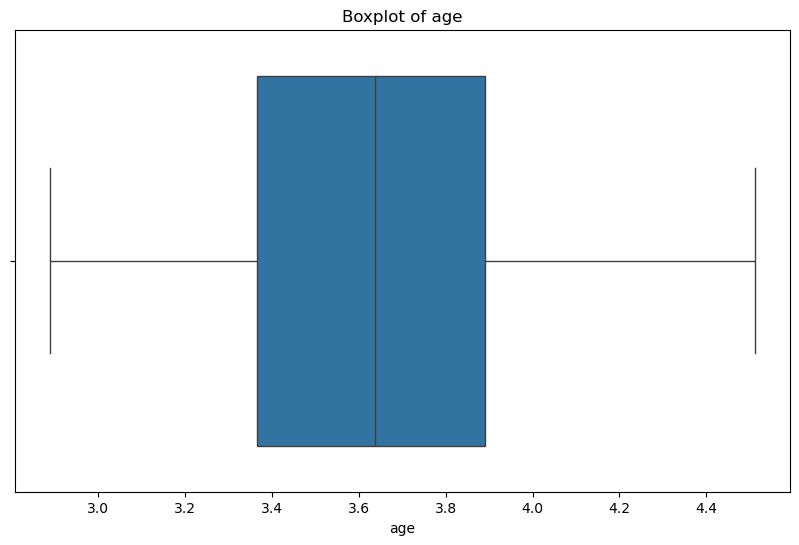

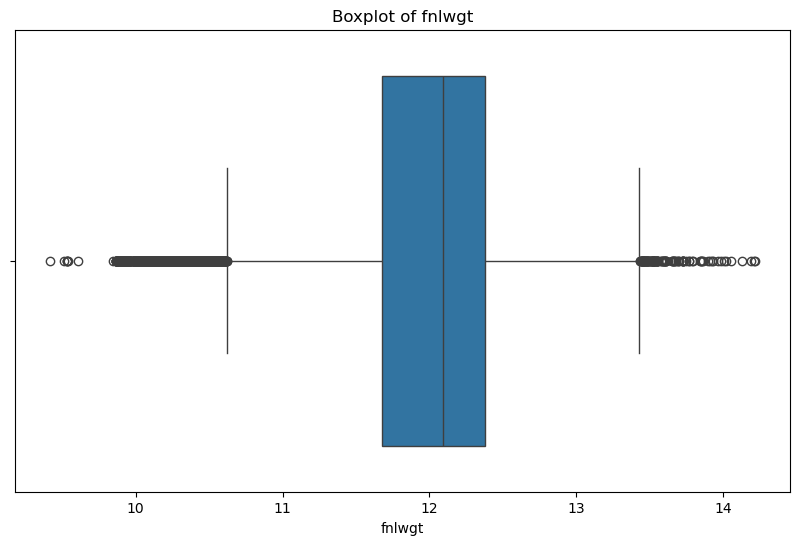

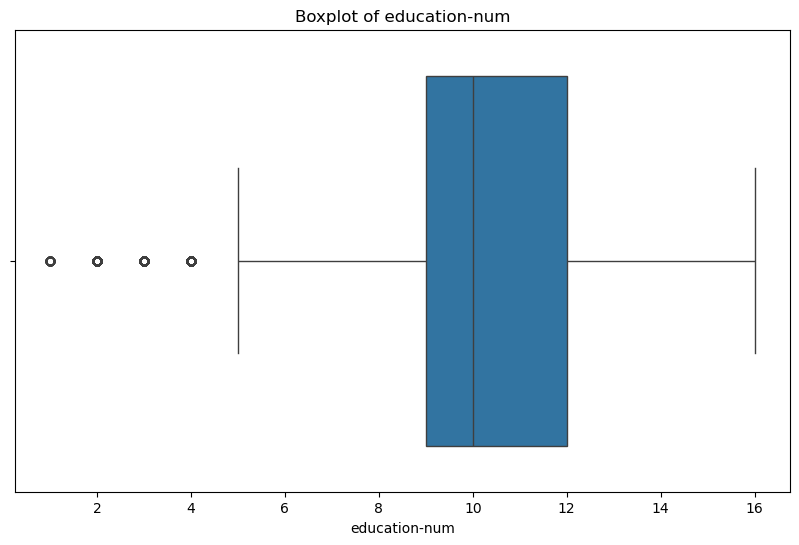

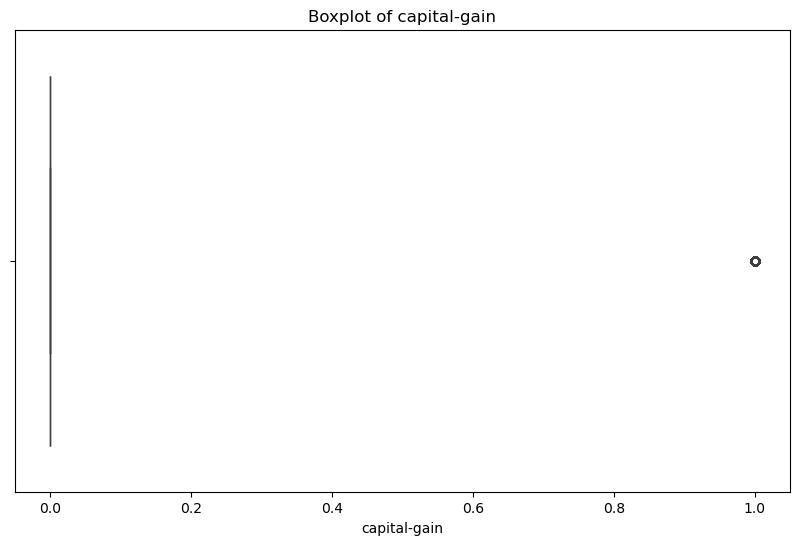

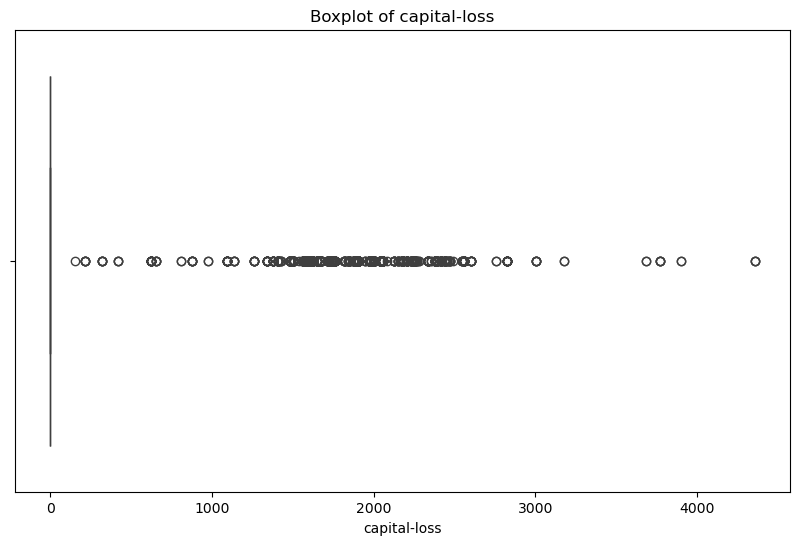

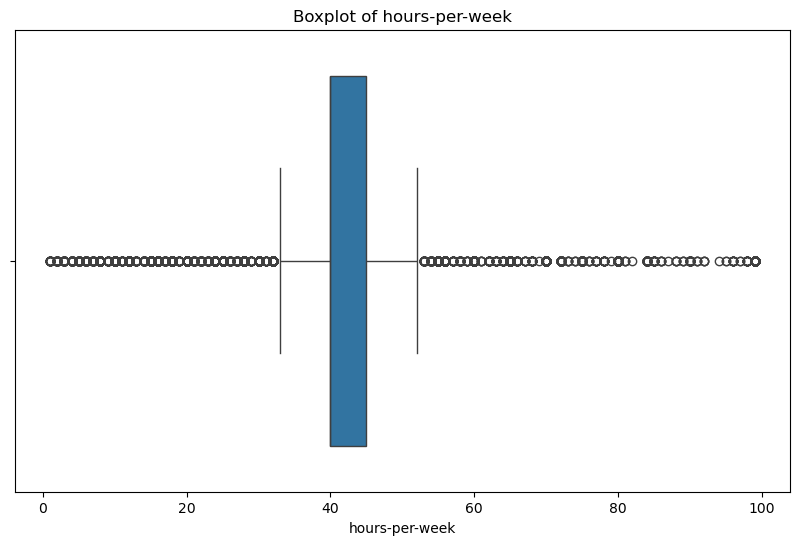

In [62]:
for feature in numerical_features:
    plot_boxplot(df, feature)

In [63]:
categorical_columns = df.select_dtypes(include=['object']).columns

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48790 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             48790 non-null  float64
 1   workclass       48790 non-null  object 
 2   fnlwgt          48790 non-null  float64
 3   education       48790 non-null  object 
 4   education-num   48790 non-null  int64  
 5   marital-status  48790 non-null  object 
 6   occupation      48790 non-null  object 
 7   relationship    48790 non-null  object 
 8   race            48790 non-null  object 
 9   sex             48790 non-null  object 
 10  capital-gain    48790 non-null  int64  
 11  capital-loss    48790 non-null  int64  
 12  hours-per-week  48790 non-null  int64  
 13  native-country  48790 non-null  object 
 14  target          48790 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 6.0+ MB


In [64]:
categorical_columns

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'target'],
      dtype='object')

In [66]:
# function to plot categorical variable distribution
def plot_categorical_distribution(df, column):
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=column, order=df[column].value_counts().index)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.grid(False)
    plt.show()

In [69]:
df['education'].value_counts()

education
HS-grad         15770
Some-college    10863
Bachelors        8013
Masters          2656
Assoc-voc        2060
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           954
Prof-school       834
9th               756
12th              655
Doctorate         594
5th-6th           507
1st-4th           245
Preschool          81
Name: count, dtype: int64

In [70]:
education_order = {
    'Preschool': 0,
    '1st-4th': 1,
    '5th-6th': 2,
    '7th-8th': 3,
    '9th': 4,
    '10th': 5,
    '11th': 6,
    '12th': 7,
    'HS-grad': 8,
    'Some-college': 9,
    'Assoc-voc': 10,
    'Assoc-acdm': 11,
    'Bachelors': 12,
    'Masters': 13,
    'Prof-school': 14,
    'Doctorate': 15
}

df['education'] = df['education'].map(education_order)


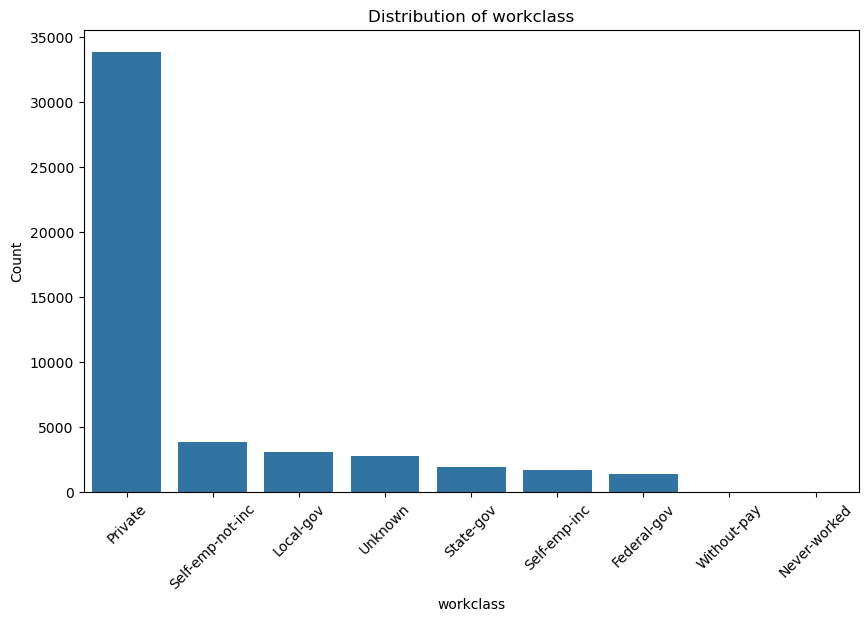

In [67]:
plot_categorical_distribution(df, 'workclass')

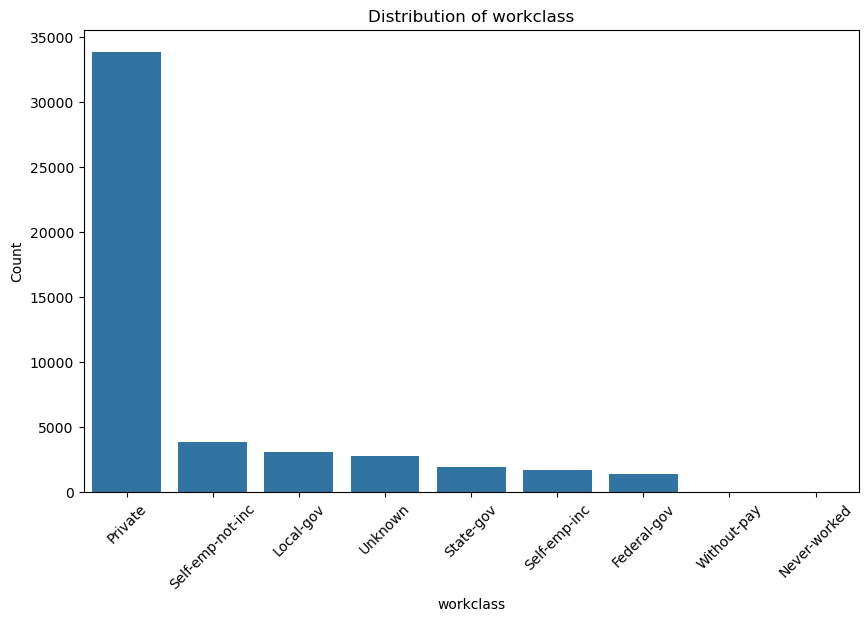

In [71]:
plot_categorical_distribution(df, 'workclass')

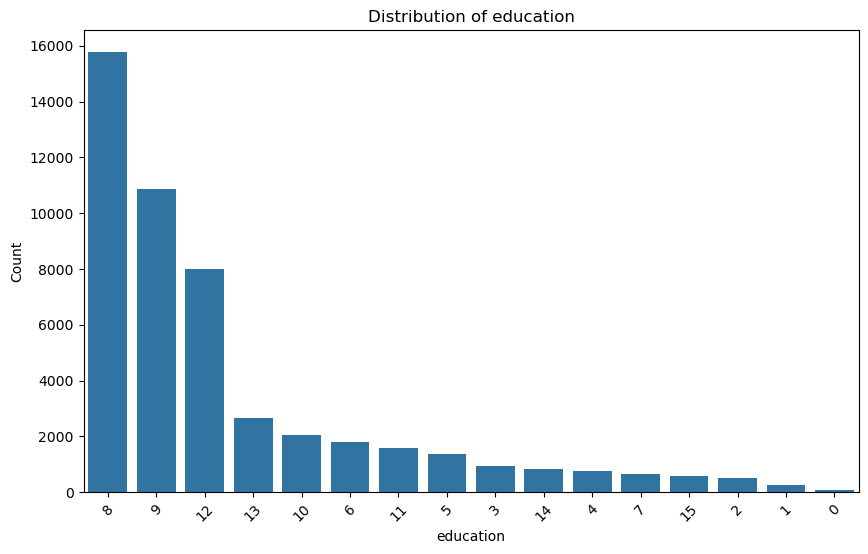

In [72]:
plot_categorical_distribution(df, 'education')

In [73]:
categorical_columns

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'target'],
      dtype='object')

In [74]:
df['marital-status'].value_counts()

marital-status
Married-civ-spouse       22366
Never-married            16082
Divorced                  6630
Separated                 1530
Widowed                   1518
Married-spouse-absent      627
Married-AF-spouse           37
Name: count, dtype: int64

In [75]:
df['marital-status'] = df['marital-status'].apply(lambda x: 1 if x in ['Married-civ-spouse', 'Married-AF-spouse'] else 0)


In [76]:
categorical_columns

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'target'],
      dtype='object')

In [79]:
df['occupation'].value_counts()

occupation
Prof-specialty       6165
Craft-repair         6102
Exec-managerial      6082
Adm-clerical         5606
Sales                5501
Other-service        4919
Machine-op-inspct    3017
Unknown              2805
Transport-moving     2355
Handlers-cleaners    2071
Farming-fishing      1485
Tech-support         1445
Protective-serv       982
Priv-house-serv       240
Armed-Forces           15
Name: count, dtype: int64

In [80]:
# Convert target to binary: 1 if >50K, else 0
df['target_binary'] = df['target'].apply(lambda x: 1 if x == '>50K' else 0)

# Target mean encoding for occupation
occupation_target_mean = df.groupby('occupation')['target_binary'].mean()

# Map to the original DataFrame
df['occupation'] = df['occupation'].map(occupation_target_mean)

# Handle unknown or missing
global_mean = df['target_binary'].mean()
df['occupation'] = df['occupation'].fillna(global_mean)


In [81]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target,target_binary
0,3.688879,State-gov,11.258253,12,13,0,0.136996,Not-in-family,White,Male,1,0,40,United-States,<=50K,0
1,3.931826,Self-emp-not-inc,11.330348,12,13,1,0.477803,Husband,White,Male,0,0,13,United-States,<=50K,0
2,3.663562,Private,12.281398,8,9,0,0.066634,Not-in-family,White,Male,0,0,40,United-States,<=50K,0
3,3.988984,Private,12.366157,6,7,1,0.066634,Husband,Black,Male,0,0,40,United-States,<=50K,0
4,3.367296,Private,12.732013,12,13,1,0.451257,Wife,Black,Female,0,0,40,Cuba,<=50K,0


In [82]:
#remove the original target column
df = df.drop(columns=['target'])
# rename the target column to 'target'
df = df.rename(columns={'target_binary': 'target'})

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,3.688879,State-gov,11.258253,12,13,0,0.136996,Not-in-family,White,Male,1,0,40,United-States,0
1,3.931826,Self-emp-not-inc,11.330348,12,13,1,0.477803,Husband,White,Male,0,0,13,United-States,0
2,3.663562,Private,12.281398,8,9,0,0.066634,Not-in-family,White,Male,0,0,40,United-States,0
3,3.988984,Private,12.366157,6,7,1,0.066634,Husband,Black,Male,0,0,40,United-States,0
4,3.367296,Private,12.732013,12,13,1,0.451257,Wife,Black,Female,0,0,40,Cuba,0


In [83]:
categorical_columns

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'target'],
      dtype='object')

In [84]:
df['relationship'].value_counts()

relationship
Husband           19703
Not-in-family     12557
Own-child          7569
Unmarried          5124
Wife               2331
Other-relative     1506
Name: count, dtype: int64

In [85]:
# Target mean encoding
relationship_target_mean = df.groupby('relationship')['target'].mean()
df['relationship'] = df['relationship'].map(relationship_target_mean)

# Fill missing with global mean
df['relationship'] = df['relationship'].fillna(df['target'].mean())

In [86]:
categorical_columns

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'target'],
      dtype='object')

In [87]:
df['race'].value_counts()

race
White                 41714
Black                  4683
Asian-Pac-Islander     1517
Amer-Indian-Eskimo      470
Other                   406
Name: count, dtype: int64

In [88]:
race_target_mean = df.groupby('race')['target'].mean()
df['race'] = df['race'].map(race_target_mean)

In [90]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,3.688879,State-gov,11.258253,12,13,0,0.136996,0.101617,0.254135,Male,1,0,40,United-States,0
1,3.931826,Self-emp-not-inc,11.330348,12,13,1,0.477803,0.448663,0.254135,Male,0,0,13,United-States,0
2,3.663562,Private,12.281398,8,9,0,0.066634,0.101617,0.254135,Male,0,0,40,United-States,0
3,3.988984,Private,12.366157,6,7,1,0.066634,0.448663,0.120863,Male,0,0,40,United-States,0
4,3.367296,Private,12.732013,12,13,1,0.451257,0.468897,0.120863,Female,0,0,40,Cuba,0


In [91]:
df['sex'].value_counts()

sex
Male      32614
Female    16176
Name: count, dtype: int64

In [92]:
categorical_columns

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'target'],
      dtype='object')

In [ ]:
df['country'].unique()

array(['United-States', 'Cuba', 'Jamaica', 'India', 'Mexico', 'South',
       'Puerto-Rico', 'Honduras', 'England', 'Canada', 'Germany', 'Iran',
       'Philippines', 'Italy', 'Poland', 'Columbia', 'Cambodia',
       'Thailand', 'Ecuador', 'Laos', 'Taiwan', 'Haiti', 'Portugal',
       'Dominican-Republic', 'El-Salvador', 'France', 'Guatemala',
       'China', 'Japan', 'Yugoslavia', 'Peru',
       'Outlying-US(Guam-USVI-etc)', 'Scotland', 'Trinadad&Tobago',
       'Greece', 'Nicaragua', 'Vietnam', 'Hong', 'Ireland', 'Hungary',
       'Holand-Netherlands'], dtype=object)

In [95]:
# Target mean encoding
country_target_mean = df.groupby('native-country')['target'].mean()
df['native-country'] = df['native-country'].map(country_target_mean)

In [96]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,3.688879,State-gov,11.258253,12,13,0,0.136996,0.101617,0.254135,Male,1,0,40,0.244311,0
1,3.931826,Self-emp-not-inc,11.330348,12,13,1,0.477803,0.448663,0.254135,Male,0,0,13,0.244311,0
2,3.663562,Private,12.281398,8,9,0,0.066634,0.101617,0.254135,Male,0,0,40,0.244311,0
3,3.988984,Private,12.366157,6,7,1,0.066634,0.448663,0.120863,Male,0,0,40,0.244311,0
4,3.367296,Private,12.732013,12,13,1,0.451257,0.468897,0.120863,Female,0,0,40,0.246377,0


In [97]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'target'],
      dtype='object')

In [98]:
df_encoded = pd.get_dummies(df, columns=['workclass', 'sex'], drop_first=True)
df_encoded

,age,fnlwgt,education,education-num,marital-status,occupation,relationship,race,capital-gain,capital-loss,...,target,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Unknown,workclass_Without-pay,sex_Male
0,3.688879,11.258253,12,13,0,0.136996,0.101617,0.254135,1,0,...,0,False,False,False,False,False,True,False,False,True
1,3.931826,11.330348,12,13,1,0.477803,0.448663,0.254135,0,0,...,0,False,False,False,False,True,False,False,False,True
2,3.663562,12.281398,8,9,0,0.066634,0.101617,0.254135,0,0,...,0,False,False,True,False,False,False,False,False,True
3,3.988984,12.366157,6,7,1,0.066634,0.448663,0.120863,0,0,...,0,False,False,True,False,False,False,False,False,True
4,3.367296,12.732013,12,13,1,0.451257,0.468897,0.120863,0,0,...,0,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,3.688879,12.280345,12,13,0,0.451257,0.101617,0.254135,0,0,...,0,False,False,True,False,False,False,False,False,False
48838,4.174387,12.680454,8,9,0,0.094474,0.034529,0.120863,0,0,...,0,False,False,False,False,False,False,True,False,True
48839,3.663562,12.834639,12,13,1,0.451257,0.448663,0.254135,0,0,...,0,False,False,True,False,False,False,False,False,True
48840,3.806662,11.337286,12,13,0,0.136996,0.014665,0.269611,1,0,...,0,False,False,True,False,False,False,False,False,True


In [100]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48790 entries, 0 to 48841
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         48790 non-null  float64
 1   fnlwgt                      48790 non-null  float64
 2   education                   48790 non-null  int64  
 3   education-num               48790 non-null  int64  
 4   marital-status              48790 non-null  int64  
 5   occupation                  48790 non-null  float64
 6   relationship                48790 non-null  float64
 7   race                        48790 non-null  float64
 8   capital-gain                48790 non-null  int64  
 9   capital-loss                48790 non-null  int64  
 10  hours-per-week              48790 non-null  int64  
 11  native-country              48790 non-null  float64
 12  target                      48790 non-null  int64  
 13  workclass_Local-gov         48790 no

In [101]:
df_encoded.to_csv('2_preprocessed_encoded.csv', index=False)
# Check the final shape of the DataFrame    
df_encoded.shape

(48790, 22)

In [102]:
df_encoded.head()

,age,fnlwgt,education,education-num,marital-status,occupation,relationship,race,capital-gain,capital-loss,...,target,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Unknown,workclass_Without-pay,sex_Male
0,3.688879,11.258253,12,13,0,0.136996,0.101617,0.254135,1,0,...,0,False,False,False,False,False,True,False,False,True
1,3.931826,11.330348,12,13,1,0.477803,0.448663,0.254135,0,0,...,0,False,False,False,False,True,False,False,False,True
2,3.663562,12.281398,8,9,0,0.066634,0.101617,0.254135,0,0,...,0,False,False,True,False,False,False,False,False,True
3,3.988984,12.366157,6,7,1,0.066634,0.448663,0.120863,0,0,...,0,False,False,True,False,False,False,False,False,True
4,3.367296,12.732013,12,13,1,0.451257,0.468897,0.120863,0,0,...,0,False,False,True,False,False,False,False,False,False


In [3]:
import pandas as pd
df=pd.read_csv('2_preprocessed_encoded.csv')
# Check the final shape of the DataFrame
df.shape

(48790, 22)

In [4]:
df['target'].value_counts()

target
0    37109
1    11681
Name: count, dtype: int64